<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


 ## Hands-on Lab: Complete the EDA with Visualization


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage. 

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans. 


  ## Objectives
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


----


Install the below libraries


In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab 



In [2]:
# andas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis 


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [3]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# If you were unable to complete the previous lab correctly you can uncomment and load this csv

# df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')

df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


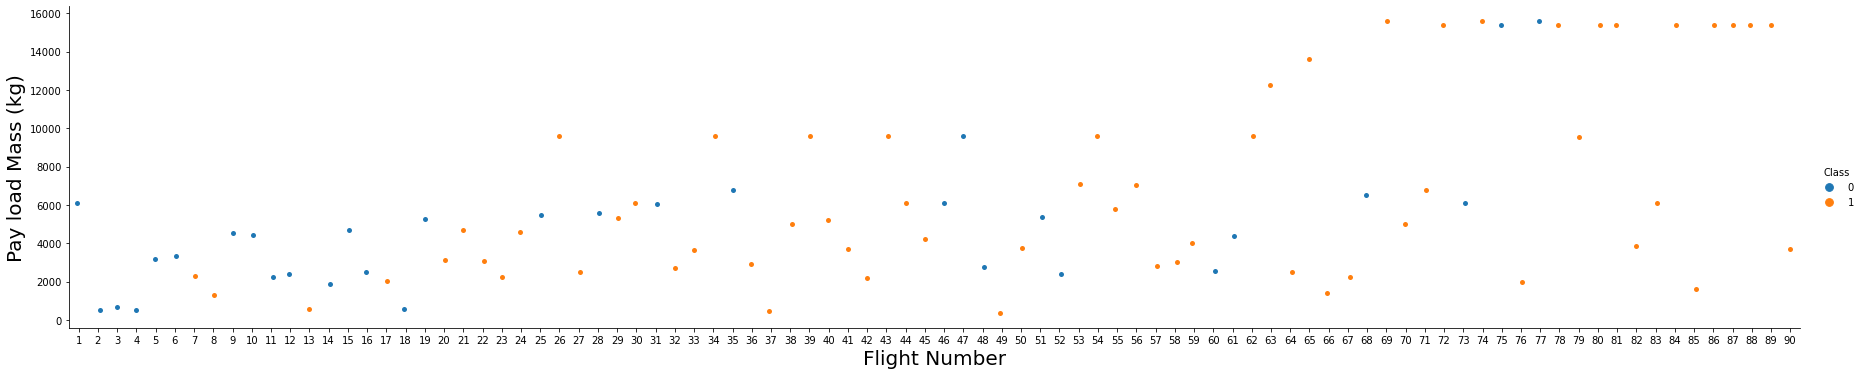

In [4]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


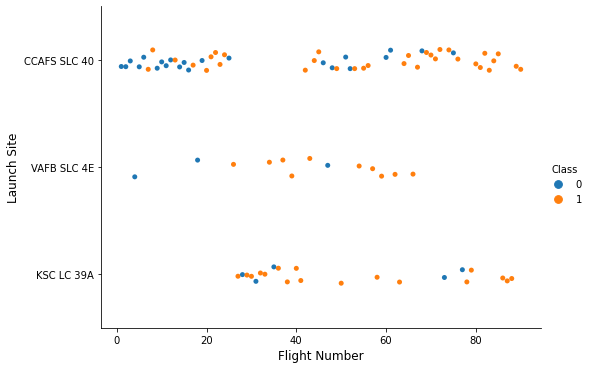

In [5]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.catplot(
    x='FlightNumber', y='LaunchSite', hue='Class',
    data=df, aspect=1.5, kind='strip'
)
plt.xlabel('Flight Number', fontsize=12)
plt.ylabel('Launch Site', fontsize=12)
plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


Diagrama de dispersión: Número de Vuelo vs. Sitio de Lanzamiento

Este diagrama de dispersión visualiza la relación entre el número de vuelo (Flight Number) y el sitio de lanzamiento (Launch Site) para cada misión. Los puntos están codificados por colores según la clase de resultado (Class), donde:

    Puntos naranjas (Clase 1): Representan misiones con un aterrizaje exitoso.

    Puntos azules (Clase 0): Representan misiones con un aterrizaje fallido.

Análisis del Diagrama de Dispersión

El diagrama muestra la distribución de los resultados de los aterrizajes en cada uno de los tres sitios de lanzamiento:

    CCAFS SLC 40: Este sitio tiene una combinación de aterrizajes exitosos y fallidos, con un número de vuelos distribuidos a lo largo del tiempo.

    VAFB SLC 4E: La mayoría de los vuelos desde este sitio resultaron en aterrizajes exitosos (puntos naranjas). Parece ser el sitio más confiable para los aterrizajes exitosos en este conjunto de datos.

    KSC LC 39A: Este sitio muestra una mezcla de resultados similares a CCAFS, con aterrizajes tanto exitosos como fallidos.

El gráfico nos permite identificar visualmente patrones en los datos. Por ejemplo, podemos ver que en general los vuelos desde VAFB SLC 4E tienden a ser exitosos, lo que podría ser una información valiosa para un análisis posterior.

### TASK 2: Visualize the relationship between Payload and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


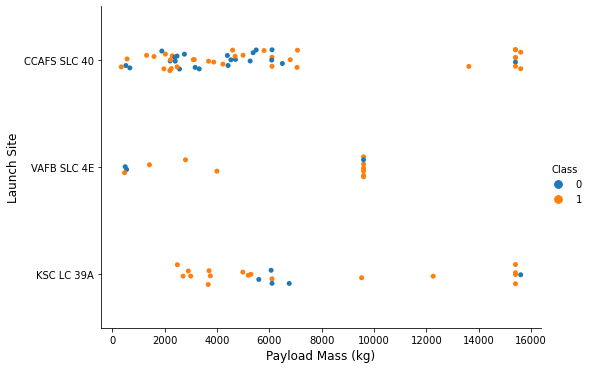

In [6]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.catplot(
    x='PayloadMass', y='LaunchSite', hue='Class',
    data=df, aspect=1.5, kind='strip'
)
plt.xlabel('Payload Mass (kg)', fontsize=12)
plt.ylabel('Launch Site', fontsize=12)
plt.show()

Now if you observe Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


Diagrama de dispersión: Masa de Carga vs. Sitio de Lanzamiento

Este diagrama de dispersión visualiza la relación entre la masa de la carga útil (Payload Mass) y el sitio de lanzamiento (Launch Site) para cada misión. Los puntos están codificados por colores según el resultado (Class):

    Puntos naranjas (Clase 1): Representan misiones con un aterrizaje exitoso.

    Puntos azules (Clase 0): Representan misiones con un aterrizaje fallido.

Análisis del Diagrama de Dispersión

El gráfico revela la distribución de los resultados de los aterrizajes en función de la masa de la carga útil en cada sitio de lanzamiento.

    CCAFS SLC 40: Este sitio maneja una amplia gama de masas de carga, desde las más ligeras hasta cargas muy pesadas. La mayoría de los aterrizajes fallidos (Class 0) ocurren con cargas ligeras a medianas, mientras que las cargas más pesadas parecen tener un mayor éxito.

    VAFB SLC 4E: La mayoría de las misiones desde este sitio tienen masas de carga relativamente bajas a medianas y, consistentemente, logran aterrizajes exitosos. No se observan aterrizajes fallidos en este sitio, lo que sugiere su alta fiabilidad.

    KSC LC 39A: Este sitio lanza misiones con cargas de masa más pesadas. Aunque hay una mezcla de resultados exitosos y fallidos, la mayoría de los aterrizajes exitosos se asocian con cargas más grandes.

El diagrama muestra que la masa de la carga útil es un factor importante, y su impacto en el éxito del aterrizaje varía según el sitio de lanzamiento.

### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


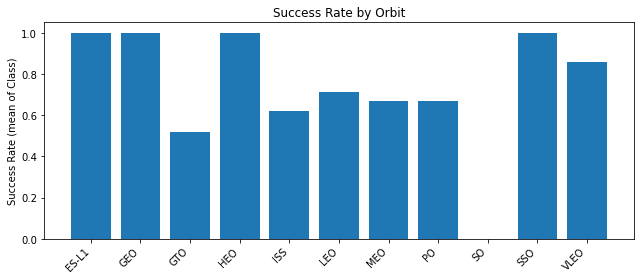

In [7]:
# HINT use groupby method on Orbit column and get the mean of Class column
orbit_success = df.groupby('Orbit', as_index=False)['Class'].mean()
plt.figure(figsize=(9,4))
plt.bar(orbit_success['Orbit'], orbit_success['Class'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Success Rate (mean of Class)')
plt.title('Success Rate by Orbit')
plt.tight_layout()
plt.show()

Analyze the ploted bar chart try to find which orbits have high sucess rate.


Tasa de Éxito por Órbita

Este gráfico de barras muestra la tasa de éxito de aterrizaje para cada tipo de órbita. La tasa de éxito se calcula como el promedio de la clase de resultado (Class), donde 1 representa un aterrizaje exitoso y 0 representa un aterrizaje fallido. Por lo tanto, una barra más alta indica una mayor probabilidad de que un cohete aterrice con éxito en esa órbita.

    Puntuaciones de 100% de éxito: Las órbitas ES-L1, GEO, HEO y SSO han logrado una tasa de éxito perfecta (1.0), lo que sugiere que todos los lanzamientos a estas órbitas en el conjunto de datos han resultado en aterrizajes exitosos.

    Puntuaciones de éxito bajas: La órbita GTO tiene la tasa de éxito más baja, con un valor de 0.5. Esto indica que la mitad de los lanzamientos a esta órbita han fallado en el aterrizaje. Las órbitas ISS y LEO también tienen tasas de éxito relativamente más bajas que la media.

    Puntuaciones de éxito moderadas: Las órbitas MEO, PO y VLEO muestran tasas de éxito moderadas, por encima del 60%, lo que sugiere que son un desafío mayor para un aterrizaje exitoso que las órbitas perfectas.

En resumen, la órbita a la que se envía un cohete tiene un gran impacto en la probabilidad de que aterrice con éxito. Las órbitas con tasas de éxito del 100% son las más fiables para aterrizajes.

### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


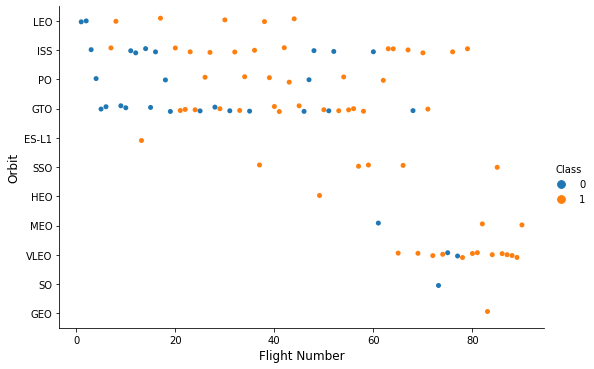

In [8]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
sns.catplot(
    x='FlightNumber', y='Orbit', hue='Class',
    data=df, aspect=1.5, kind='strip'
)
plt.xlabel('Flight Number', fontsize=12)
plt.ylabel('Orbit', fontsize=12)
plt.show()

You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.


Diagrama de dispersión: Número de vuelo vs. Órbita

Este diagrama de dispersión muestra la relación entre el número de vuelo (Flight Number) y la órbita (Orbit) para cada misión. Los puntos están codificados por colores para representar el resultado del aterrizaje (Class):

    Puntos naranjas (Clase 1): Misiones con un aterrizaje exitoso.

    Puntos azules (Clase 0): Misiones con un aterrizaje fallido.

Análisis del diagrama de dispersión

El gráfico revela la distribución de los resultados de los aterrizajes a lo largo de la cronología de los vuelos y en diferentes tipos de órbita.

    Primeros vuelos: Los primeros vuelos (números de vuelo bajos) mostraron una mayor proporción de fracasos (Class 0), especialmente en órbitas como LEO, ISS y GTO.

    Vuelos posteriores: A medida que aumenta el número de vuelo, la proporción de éxitos (Class 1) también aumenta, lo que sugiere que SpaceX mejoró su tecnología y experiencia con el tiempo. Los vuelos más recientes muestran una alta tasa de éxito, incluso en órbitas que inicialmente tuvieron fallos.

    Órbitas exitosas: Algunas órbitas, como SSO, HEO y VLEO, muestran una alta concentración de éxitos. Esto podría indicar que estas órbitas son más propicias para un aterrizaje exitoso, o que los cohetes solo se enviaron a estas órbitas una vez que la tecnología de aterrizaje estuvo más madura.

El diagrama es valioso porque muestra una clara tendencia de mejora en la tasa de éxito de los aterrizajes con el paso del tiempo, así como la variabilidad de resultados según la órbita.

### TASK  5: Visualize the relationship between Payload and Orbit type


Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


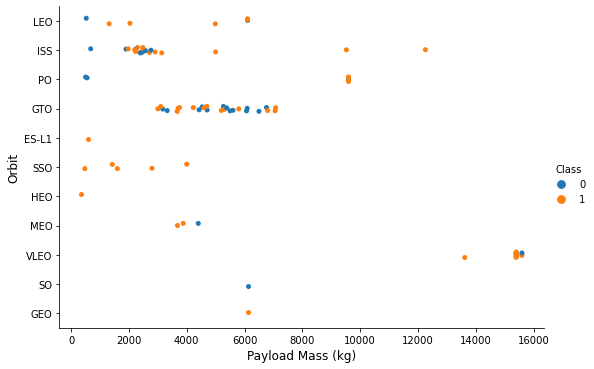

In [9]:
# Plot a scatter point chart with x axis to be Payload and y axis to be the Orbit, and hue to be the class value
sns.catplot(
    x='PayloadMass', y='Orbit', hue='Class',
    data=df, aspect=1.5, kind='strip'
)
plt.xlabel('Payload Mass (kg)', fontsize=12)
plt.ylabel('Orbit', fontsize=12)
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.   

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.




Diagrama de Dispersión: Masa de Carga vs. Órbita

Este diagrama de dispersión visualiza la relación entre la masa de la carga útil (Payload Mass) y la órbita (Orbit) para cada misión. Los puntos están codificados por colores para representar el resultado del aterrizaje (Class):

    Puntos naranjas (Clase 1): Misiones con un aterrizaje exitoso.

    Puntos azules (Clase 0): Misiones con un aterrizaje fallido.

Análisis del Diagrama de Dispersión

El gráfico destaca cómo el éxito de una misión está influenciado por la combinación de la masa de su carga útil y la órbita de destino.

    Órbitas Polares, LEO e ISS: El gráfico muestra que las misiones con cargas pesadas lanzadas a órbitas Polares (PO), Bajas Terrestres (LEO) y a la Estación Espacial Internacional (ISS) tienen una mayor tasa de aterrizajes exitosos. Esto sugiere que el modelo se desempeña bien al identificar misiones exitosas con cargas pesadas en estas clases orbitales específicas.

    Órbita de Transferencia Geoestacionaria (GTO): Para los lanzamientos a GTO, la distinción entre aterrizajes exitosos y fallidos no es tan clara. El diagrama de dispersión muestra un número significativo de puntos tanto naranjas como azules en un rango de masas de carga, lo que indica que la tasa de éxito para esta órbita es más variable. Esto hace que sea difícil sacar una conclusión sólida sobre la relación entre la masa de la carga útil y el éxito del aterrizaje para las misiones a GTO, basándose solo en esta visualización.

### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend. 


The function will help you get the year from the date:


In [10]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


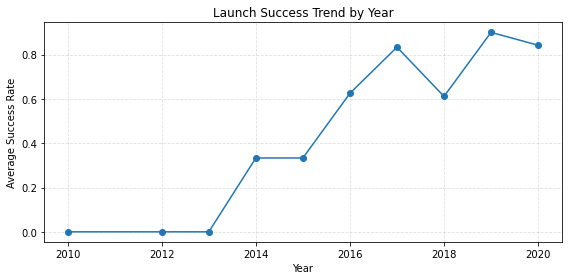

In [11]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
df_year = pd.DataFrame({'Year': df['Date'], 'Class': df['Class']})

# Agrupamos por año y calculamos el promedio de éxito
year_success = df_year.groupby('Year', as_index=False)['Class'].mean()

# Asegurar que Year es entero
year_success['Year'] = year_success['Year'].astype(int)

# Graficar usando valores planos
plt.figure(figsize=(8,4))
plt.plot(year_success['Year'].values, year_success['Class'].values, marker="o")
plt.xlabel('Year')
plt.ylabel('Average Success Rate')
plt.title('Launch Success Trend by Year')
plt.grid(True, linestyle='--', alpha=.4)
plt.tight_layout()
plt.show()

You can observe that the success rate since 2013 kept increasing till 2017 (stable in 2014) and after 2015 it started increasing.


## Features Engineering 


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [12]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


 ### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [13]:
# HINT: Use get_dummies() function on the categorical columns
features_one_hot = pd.get_dummies(
    features,
    columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'],
    dtype='uint8'
)
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,525.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,677.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,500.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,3170.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


In [14]:
# HINT: use astype function
features_one_hot = features_one_hot.astype('float64')
features_one_hot.dtypes.head()

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
dtype: object

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range. 


<code>features_one_hot.to_csv('dataset_part_3.csv', index=False)</code>


## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-10-12        | 1.1     | Lakshmi Holla     | Modified markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-10       | 1.1    | Nayef      | updating the input data |


Copyright © 2020 IBM Corporation. All rights reserved.
